In [1]:
###testing R in jyupter 

In [2]:
library(purrr)
library(tidyverse)
library(edgeR)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.6     ✔ dplyr   1.0.9
✔ tibble  3.1.7     ✔ stringr 1.4.0
✔ tidyr   1.2.0     ✔ forcats 0.5.1
✔ readr   2.1.2     

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Loading required package: limma



In [3]:
lfbl=function(pattern,level=1){
    if(!exists("lof")) lof=vector("character",0)
    temp=list.files(pattern=pattern,no..=T)
    if(!is.na(temp[1])) lof=c(lof,paste0(getwd(),"/",temp))
    if(level>0){
        dirf=list.dirs(full.names=F,recursive=F)
        for(i in dirf){
            setwd(i)
            lof=c(lof,lfbl(pattern,level-1))
            setwd("..")
        }
    }
    return(lof)
}




In [4]:
setwd("/lustre/scratch123/hgi/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/")
getwd()

[1] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount"

In [5]:
f_files = lfbl(pattern = 'featureCounts$',level=1)
f_files


[1] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-12.5dpp.1.featureCounts"
  [2] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-12.5dpp.2.featureCounts"
  [3] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-12.5dpp.3.featureCounts"
  [4] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-16.5dpc.1.featureCounts"
  [5] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-16.5dpc.2.featureCounts"
  [6] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-16.5dpc.3.featureCounts"
  [7] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-20.5dpp.1.featureCounts"
  [8] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-20.5dpp.2.featureCounts"
  [9] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-20.5dpp.3.featureCounts"
 [10] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/A_J/A_J-12.5dpp.1.featureCounts"                
 [11] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/A_J/A_J-12.5dpp.2.featureCounts"                
 [12] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/A_J/A_J-12.5dpp.3.featureCounts"                
 [13] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/A_J/A_J-16.5dpc.1.featureCounts"                
 [14] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/A_J/A_J-16.5dpc.2.featureCounts"                
 [15] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/A_J/A_J-16.5dpc.3.featureCounts"                
 [16] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/A_J/A_J-20.5dpp.1.featureCounts"                
 [17] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/A_J/A_J-20.5dpp.2.featureCounts"                
 [18] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/A_J/A_J-20.5dpp.3.featureCounts"                
 [19] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/AKR_J/AKR_J-12.5dpp.1.featureCounts"            
 [20] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/AKR_J/AKR_J-12.5dpp.2.featureCounts"            
 [21] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/AKR_J/AKR_J-12.5dpp.3.featureCounts"            
 [22] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/AKR_J/AKR_J-16.5dpc.1.featureCounts"            
 [23] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/AKR_J/AKR_J-16.5dpc.2.featureCounts"            
 [24] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/AKR_J/AKR_J-16.5dpc.3.featureCounts"            
 [25] "/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/AKR_J/AKR_J-20.5dpp.1.featureCounts"            
 [26] "/lustre/scratch123/h

In [6]:

groups = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
groups

[1] "129S1_SvImJ-12.5dpp" "129S1_SvImJ-12.5dpp" "129S1_SvImJ-12.5dpp"
  [4] "129S1_SvImJ-16.5dpc" "129S1_SvImJ-16.5dpc" "129S1_SvImJ-16.5dpc"
  [7] "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp" "129S1_SvImJ-20.5dpp"
 [10] "A_J-12.5dpp"         "A_J-12.5dpp"         "A_J-12.5dpp"        
 [13] "A_J-16.5dpc"         "A_J-16.5dpc"         "A_J-16.5dpc"        
 [16] "A_J-20.5dpp"         "A_J-20.5dpp"         "A_J-20.5dpp"        
 [19] "AKR_J-12.5dpp"       "AKR_J-12.5dpp"       "AKR_J-12.5dpp"      
 [22] "AKR_J-16.5dpc"       "AKR_J-16.5dpc"       "AKR_J-16.5dpc"      
 [25] "AKR_J-20.5dpp"       "AKR_J-20.5dpp"       "AKR_J-20.5dpp"      
 [28] "BALB_cJ-12.5dpp"     "BALB_cJ-12.5dpp"     "BALB_cJ-12.5dpp"    
 [31] "BALB_cJ-16.5dpc"     "BALB_cJ-16.5dpc"     "BALB_cJ-16.5dpc"    
 [34] "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"     "BALB_cJ-20.5dpp"    
 [37] "C3H_HeJ-12.5dpp"     "C3H_HeJ-12.5dpp"     "C3H_HeJ-12.5dpp"    
 [40] "C3H_HeJ-16.5dpc"     "C3H_HeJ-16.5dpc"     "C3H_HeJ-16.5dpc"    
 [43] "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"     "C3H_HeJ-20.5dpp"    
 [46] "C57BL_6NJ-12.5dpp"   "C57BL_6NJ-12.5dpp"   "C57BL_6NJ-12.5dpp"  
 [49] "C57BL_6NJ-16.5dpc"   "C57BL_6NJ-16.5dpc"   "C57BL_6NJ-16.5dpc"  
 [52] "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"   "C57BL_6NJ-20.5dpp"  
 [55] "CAST_EiJ-12.5dpp"    "CAST_EiJ-12.5dpp"    "CAST_EiJ-12.5dpp"   
 [58] "CAST_EiJ-16.5dpc"    "CAST_EiJ-16.5dpc"    "CAST_EiJ-16.5dpc"   
 [61] "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"    "CAST_EiJ-20.5dpp"   
 [64] "CBA_J-12.5dpp"       "CBA_J-12.5dpp"       "CBA_J-12.5dpp"      
 [67] "CBA_J-16.5dpc"       "CBA_J-16.5dpc"       "CBA_J-16.5dpc"      
 [70] "CBA_J-20.5dpp"       "CBA_J-20.5dpp"       "CBA_J-20.5dpp"      
 [73] "DBA_2J-12.5dpp"      "DBA_2J-12.5dpp"      "DBA_2J-12.5dpp"     
 [76] "DBA_2J-16.5dpc"      "DBA_2J-16.5dpc"      "DBA_2J-16.5dpc"     
 [79] "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"      "DBA_2J-20.5dpp"     
 [82] "FVB_NJ-12.5dpp"      "FVB_NJ-12.5dpp"      "FVB_NJ-12.5dpp"     
 [85] "FVB_NJ-16.5dpc"      "FVB_NJ-16.5dpc"      "FVB_NJ-16.5dpc"     
 [88] "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"      "FVB_NJ-20.5dpp"     
 [91] "LP_J-12.5dpp"        "LP_J-12.5dpp"        "LP_J-12.5dpp"       
 [94] "LP_J-16.5dpc"        "LP_J-16.5dpc"        "LP_J-16.5dpc"       
 [97] "LP_J-20.5dpp"        "LP_J-20.5dpp"        "LP_J-20.5dpp"       
[100] "NOD_ShiLtJ-12.5dpp"  "NOD_ShiLtJ-12.5dpp"  "NOD_ShiLtJ-12.5dpp" 
[103] "NOD_ShiLtJ-16.5dpc"  "NOD_ShiLtJ-16.5dpc"  "NOD_ShiLtJ-16.5dpc" 
[106] "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp"  "NOD_ShiLtJ-20.5dpp" 
[109] "NZO_HlLtJ-12.5dpp"   "NZO_HlLtJ-12.5dpp"   "NZO_HlLtJ-12.5dpp"  
[112] "NZO_HlLtJ-16.5dpc"   "NZO_HlLtJ-16.5dpc"   "NZO_HlLtJ-16.5dpc"  
[115] "NZO_HlLtJ-20.5dpp"   "NZO_HlLtJ-20.5dpp"   "NZO_HlLtJ-20.5dpp"  
[118] "PWK_PhJ-12.5dpp"     "PWK_PhJ-12.5dpp"     "PWK_PhJ-12.5dpp"    
[121] "PWK_PhJ-16.5dpc"     "PWK_PhJ-16.5dpc"     "PWK_PhJ-16.5dpc"    
[124] "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"     "PWK_PhJ-20.5dpp"    
[127] "SPRET_EiJ-12.5dpp"   "SPRET_EiJ-12.5dpp"   "SPRET_EiJ-12.5dpp"  
[130] "SPRET_EiJ-16.5dpc"   "SPRET_EiJ-16.5dpc"   "SPRET_EiJ-16.5dpc"  
[133] "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"   "SPRET_EiJ-20.5dpp"  
[136] "WSB_EiJ-12.5dpp"     "WSB_EiJ-12.5dpp"     "WSB_EiJ-12.5dpp"    
[139] "WSB_EiJ-16.5dpc"     "WSB_EiJ-16.5dpc"     "WSB_EiJ-16.5dpc"    
[142] "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"     "WSB_EiJ-20.5dpp"

In [7]:

#list of sample names with replicates 
lables = tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))

lables

[1] "129S1_SvImJ-12.5dpp.1" "129S1_SvImJ-12.5dpp.2" "129S1_SvImJ-12.5dpp.3"
  [4] "129S1_SvImJ-16.5dpc.1" "129S1_SvImJ-16.5dpc.2" "129S1_SvImJ-16.5dpc.3"
  [7] "129S1_SvImJ-20.5dpp.1" "129S1_SvImJ-20.5dpp.2" "129S1_SvImJ-20.5dpp.3"
 [10] "A_J-12.5dpp.1"         "A_J-12.5dpp.2"         "A_J-12.5dpp.3"        
 [13] "A_J-16.5dpc.1"         "A_J-16.5dpc.2"         "A_J-16.5dpc.3"        
 [16] "A_J-20.5dpp.1"         "A_J-20.5dpp.2"         "A_J-20.5dpp.3"        
 [19] "AKR_J-12.5dpp.1"       "AKR_J-12.5dpp.2"       "AKR_J-12.5dpp.3"      
 [22] "AKR_J-16.5dpc.1"       "AKR_J-16.5dpc.2"       "AKR_J-16.5dpc.3"      
 [25] "AKR_J-20.5dpp.1"       "AKR_J-20.5dpp.2"       "AKR_J-20.5dpp.3"      
 [28] "BALB_cJ-12.5dpp.1"     "BALB_cJ-12.5dpp.2"     "BALB_cJ-12.5dpp.3"    
 [31] "BALB_cJ-16.5dpc.1"     "BALB_cJ-16.5dpc.2"     "BALB_cJ-16.5dpc.3"    
 [34] "BALB_cJ-20.5dpp.1"     "BALB_cJ-20.5dpp.2"     "BALB_cJ-20.5dpp.3"    
 [37] "C3H_HeJ-12.5dpp.1"     "C3H_HeJ-12.5dpp.2"     "C3H_HeJ-12.5dpp.3"    
 [40] "C3H_HeJ-16.5dpc.1"     "C3H_HeJ-16.5dpc.2"     "C3H_HeJ-16.5dpc.3"    
 [43] "C3H_HeJ-20.5dpp.1"     "C3H_HeJ-20.5dpp.2"     "C3H_HeJ-20.5dpp.3"    
 [46] "C57BL_6NJ-12.5dpp.1"   "C57BL_6NJ-12.5dpp.2"   "C57BL_6NJ-12.5dpp.3"  
 [49] "C57BL_6NJ-16.5dpc.1"   "C57BL_6NJ-16.5dpc.2"   "C57BL_6NJ-16.5dpc.3"  
 [52] "C57BL_6NJ-20.5dpp.1"   "C57BL_6NJ-20.5dpp.2"   "C57BL_6NJ-20.5dpp.3"  
 [55] "CAST_EiJ-12.5dpp.1"    "CAST_EiJ-12.5dpp.2"    "CAST_EiJ-12.5dpp.3"   
 [58] "CAST_EiJ-16.5dpc.1"    "CAST_EiJ-16.5dpc.2"    "CAST_EiJ-16.5dpc.3"   
 [61] "CAST_EiJ-20.5dpp.1"    "CAST_EiJ-20.5dpp.2"    "CAST_EiJ-20.5dpp.3"   
 [64] "CBA_J-12.5dpp.1"       "CBA_J-12.5dpp.2"       "CBA_J-12.5dpp.3"      
 [67] "CBA_J-16.5dpc.1"       "CBA_J-16.5dpc.2"       "CBA_J-16.5dpc.3"      
 [70] "CBA_J-20.5dpp.1"       "CBA_J-20.5dpp.2"       "CBA_J-20.5dpp.3"      
 [73] "DBA_2J-12.5dpp.1"      "DBA_2J-12.5dpp.2"      "DBA_2J-12.5dpp.3"     
 [76] "DBA_2J-16.5dpc.1"      "DBA_2J-16.5dpc.2"      "DBA_2J-16.5dpc.3"     
 [79] "DBA_2J-20.5dpp.1"      "DBA_2J-20.5dpp.2"      "DBA_2J-20.5dpp.3"     
 [82] "FVB_NJ-12.5dpp.1"      "FVB_NJ-12.5dpp.2"      "FVB_NJ-12.5dpp.3"     
 [85] "FVB_NJ-16.5dpc.1"      "FVB_NJ-16.5dpc.2"      "FVB_NJ-16.5dpc.3"     
 [88] "FVB_NJ-20.5dpp.1"      "FVB_NJ-20.5dpp.2"      "FVB_NJ-20.5dpp.3"     
 [91] "LP_J-12.5dpp.1"        "LP_J-12.5dpp.2"        "LP_J-12.5dpp.3"       
 [94] "LP_J-16.5dpc.1"        "LP_J-16.5dpc.2"        "LP_J-16.5dpc.3"       
 [97] "LP_J-20.5dpp.1"        "LP_J-20.5dpp.2"        "LP_J-20.5dpp.3"       
[100] "NOD_ShiLtJ-12.5dpp.1"  "NOD_ShiLtJ-12.5dpp.2"  "NOD_ShiLtJ-12.5dpp.3" 
[103] "NOD_ShiLtJ-16.5dpc.1"  "NOD_ShiLtJ-16.5dpc.2"  "NOD_ShiLtJ-16.5dpc.3" 
[106] "NOD_ShiLtJ-20.5dpp.1"  "NOD_ShiLtJ-20.5dpp.2"  "NOD_ShiLtJ-20.5dpp.3" 
[109] "NZO_HlLtJ-12.5dpp.1"   "NZO_HlLtJ-12.5dpp.2"   "NZO_HlLtJ-12.5dpp.3"  
[112] "NZO_HlLtJ-16.5dpc.1"   "NZO_HlLtJ-16.5dpc.2"   "NZO_HlLtJ-16.5dpc.3"  
[115] "NZO_HlLtJ-20.5dpp.1"   "NZO_HlLtJ-20.5dpp.2"   "NZO_HlLtJ-20.5dpp.3"  
[118] "PWK_PhJ-12.5dpp.1"     "PWK_PhJ-12.5dpp.2"     "PWK_PhJ-12.5dpp.3"    
[121] "PWK_PhJ-16.5dpc.1"     "PWK_PhJ-16.5dpc.2"     "PWK_PhJ-16.5dpc.3"    
[124] "PWK_PhJ-20.5dpp.1"     "PWK_PhJ-20.5dpp.2"     "PWK_PhJ-20.5dpp.3"    
[127] "SPRET_EiJ-12.5dpp.1"   "SPRET_EiJ-12.5dpp.2"   "SPRET_EiJ-12.5dpp.3"  
[130] "SPRET_EiJ-16.5dpc.1"   "SPRET_EiJ-16.5dpc.2"   "SPRET_EiJ-16.5dpc.3"  
[133] "SPRET_EiJ-20.5dpp.1"   "SPRET_EiJ-20.5dpp.2"   "SPRET_EiJ-20.5dpp.3"  
[136] "WSB_EiJ-12.5dpp.1"     "WSB_EiJ-12.5dpp.2"     "WSB_EiJ-12.5dpp.3"    
[139] "WSB_EiJ-16.5dpc.1"     "WSB_EiJ-16.5dpc.2"     "WSB_EiJ-16.5dpc.3"    
[142] "WSB_EiJ-20.5dpp.1"     "WSB_EiJ-20.5dpp.2"     "WSB_EiJ-20.5dpp.3"

In [8]:
	
df = readDGE(f_files, path=NULL, columns=c(1,7), group= groups, labels = lables,sep="\t" ,skip = 1)

In [9]:
head(df)

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
129S1_SvImJ-12.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-12.5dpp.1.featureCounts,129S1_SvImJ-12.5dpp,15481276,1
129S1_SvImJ-12.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-12.5dpp.2.featureCounts,129S1_SvImJ-12.5dpp,23548654,1
129S1_SvImJ-12.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-12.5dpp.3.featureCounts,129S1_SvImJ-12.5dpp,14756989,1
129S1_SvImJ-16.5dpc.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-16.5dpc.1.featureCounts,129S1_SvImJ-16.5dpc,5623140,1
129S1_SvImJ-16.5dpc.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-16.5dpc.2.featureCounts,129S1_SvImJ-16.5dpc,5423090,1
129S1_SvImJ-16.5dpc.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-16.5dpc.3.featureCounts,129S1_SvImJ-16.5dpc,6203483,1
129S1_SvImJ-20.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-20.5dpp.1.featureCounts,129S1_SvImJ-20.5dpp,5760155,1
129S1_SvImJ-20.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-20.5dpp.2.featureCounts,129S1_SvImJ-20.5dpp,5645135,1
129S1_SvImJ-20.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-20.5dpp.3.featureCounts,129S1_SvImJ-20.5dpp,5538772,1


In [10]:
mircounts <- df$counts

In [11]:
df$samples

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
129S1_SvImJ-12.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-12.5dpp.1.featureCounts,129S1_SvImJ-12.5dpp,15481276,1
129S1_SvImJ-12.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-12.5dpp.2.featureCounts,129S1_SvImJ-12.5dpp,23548654,1
129S1_SvImJ-12.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-12.5dpp.3.featureCounts,129S1_SvImJ-12.5dpp,14756989,1
129S1_SvImJ-16.5dpc.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-16.5dpc.1.featureCounts,129S1_SvImJ-16.5dpc,5623140,1
129S1_SvImJ-16.5dpc.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-16.5dpc.2.featureCounts,129S1_SvImJ-16.5dpc,5423090,1
129S1_SvImJ-16.5dpc.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-16.5dpc.3.featureCounts,129S1_SvImJ-16.5dpc,6203483,1
129S1_SvImJ-20.5dpp.1,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-20.5dpp.1.featureCounts,129S1_SvImJ-20.5dpp,5760155,1
129S1_SvImJ-20.5dpp.2,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-20.5dpp.2.featureCounts,129S1_SvImJ-20.5dpp,5645135,1
129S1_SvImJ-20.5dpp.3,/lustre/scratch123/hgi/mdt2/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/results/transcriptCount/129S1_SvImJ/129S1_SvImJ-20.5dpp.3.featureCounts,129S1_SvImJ-20.5dpp,5538772,1


In [12]:
#DESeq and PCA and Dandogram 


library("DESeq2")
library("gplots")
library("RColorBrewer")
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

#save results in this folder 
setwd("/lustre/scratch123/hgi/projects/mouse_epi/users/naru/inProgres/mice_PiRNA/analysis/transcriptCount/strains")

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:dplyr’:

    first, rename


The following object is masked from ‘packa

In [13]:
# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)

In [14]:
# First we tell DESeq which samples correspond to which tissues.
samplenames <- tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
conds = data.frame(samplenames) ##what Desq2 manual calls coldata
colnames(conds)="sample"


In [15]:
# Now we build a DESeq2 Count dataset and normalize it.
cds <- DESeqDataSetFromMatrix(countData = round(mircounts), colData = conds, design = ~ sample)
cds <- estimateSizeFactors(cds)
cds <- estimateDispersions(cds)
cds <- nbinomWaldTest(cds)


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substi

In [18]:
#rlog normalisations
#rlog() may take a long time with 50 or more samples,
#vst() is a much faster transformation
#rl=rlog(cds)

rl = vst(cds)

In [19]:

pdf("BarGraphBeforeAfter.pdf",paper="a4")
par(mfrow=c(2,1))

par(mar=c(10,4,0,2)) # increase y-axis margin.
prenorm=apply(mircounts,2,sum)
barplot(prenorm,col=as.factor(samplenames),las=2,names=samplenames,cex.axis = .7, cex.names=.6,beside=TRUE, border="white")

postnorm=apply(counts(cds,normalized=TRUE),2,sum)
barplot(postnorm,col=as.factor(samplenames),las=2,names=samplenames,cex.axis = .7, cex.names=.6,beside=TRUE, border="white")
dev.off()


png 
  2

In [20]:
prenorm

129S1_SvImJ-12.5dpp.1 129S1_SvImJ-12.5dpp.2 129S1_SvImJ-12.5dpp.3 
             15481276              23548654              14756989 
129S1_SvImJ-16.5dpc.1 129S1_SvImJ-16.5dpc.2 129S1_SvImJ-16.5dpc.3 
              5623140               5423090               6203483 
129S1_SvImJ-20.5dpp.1 129S1_SvImJ-20.5dpp.2 129S1_SvImJ-20.5dpp.3 
              5760155               5645135               5538772 
        A_J-12.5dpp.1         A_J-12.5dpp.2         A_J-12.5dpp.3 
             14426317              23233591              14569090 
        A_J-16.5dpc.1         A_J-16.5dpc.2         A_J-16.5dpc.3 
              8472065               4979495              10151158 
        A_J-20.5dpp.1         A_J-20.5dpp.2         A_J-20.5dpp.3 
              4731147               5378979               6333018 
      AKR_J-12.5dpp.1       AKR_J-12.5dpp.2       AKR_J-12.5dpp.3 
             25059795              22676719              22444203 
      AKR_J-16.5dpc.1       AKR_J-16.5dpc.2       AKR_J-16.5dpc.3 
              6386642               6126645               6115655 
      AKR_J-20.5dpp.1       AKR_J-20.5dpp.2       AKR_J-20.5dpp.3 
              4886236               5586644               5466023 
    BALB_cJ-12.5dpp.1     BALB_cJ-12.5dpp.2     BALB_cJ-12.5dpp.3 
             37987118              33256246              50477126 
    BALB_cJ-16.5dpc.1     BALB_cJ-16.5dpc.2     BALB_cJ-16.5dpc.3 
              7033192               7104085               6056895 
    BALB_cJ-20.5dpp.1     BALB_cJ-20.5dpp.2     BALB_cJ-20.5dpp.3 
             26202720              27195309              25039316 
    C3H_HeJ-12.5dpp.1     C3H_HeJ-12.5dpp.2     C3H_HeJ-12.5dpp.3 
             17835529              19106699              15119396 
    C3H_HeJ-16.5dpc.1     C3H_HeJ-16.5dpc.2     C3H_HeJ-16.5dpc.3 
              7883964               5915913               7283988 
    C3H_HeJ-20.5dpp.1     C3H_HeJ-20.5dpp.2     C3H_HeJ-20.5dpp.3 
              6269259              15758568              12961983 
  C57BL_6NJ-12.5dpp.1   C57BL_6NJ-12.5dpp.2   C57BL_6NJ-12.5dpp.3 
             34131117              33459012              29653141 
  C57BL_6NJ-16.5dpc.1   C57BL_6NJ-16.5dpc.2   C57BL_6NJ-16.5dpc.3 
              6713301               6685263               9246629 
  C57BL_6NJ-20.5dpp.1   C57BL_6NJ-20.5dpp.2   C57BL_6NJ-20.5dpp.3 
             15479027              21610841              21051031 
   CAST_EiJ-12.5dpp.1    CAST_EiJ-12.5dpp.2    CAST_EiJ-12.5dpp.3 
             41725676              46518093              59535808 
   CAST_EiJ-16.5dpc.1    CAST_EiJ-16.5dpc.2    CAST_EiJ-16.5dpc.3 
              8915149               6799220               7681770 
   CAST_EiJ-20.5dpp.1    CAST_EiJ-20.5dpp.2    CAST_EiJ-20.5dpp.3 
             23400696              16305576              23990324 
      CBA_J-12.5dpp.1       CBA_J-12.5dpp.2       CBA_J-12.5dpp.3 
             25499629              21069471              27815490 
      CBA_J-16.5dpc.1       CBA_J-16.5dpc.2       CBA_J-16.5dpc.3 
             10543356               5334047               7093706 
      CBA_J-20.5dpp.1       CBA_J-20.5dpp.2       CBA_J-20.5dpp.3 
             14922183               5380345              14471214 
     DBA_2J-12.5dpp.1      DBA_2J-12.5dpp.2      DBA_2J-12.5dpp.3 
             13526135              15191020              22617901 
     DBA_2J-16.5dpc.1      DBA_2J-16.5dpc.2      DBA_2J-16.5dpc.3 
              7847035               6796788               5516523 
     DBA_2J-20.5dpp.1      DBA_2J-20.5dpp.2      DBA_2J-20.5dpp.3 
              5701249               5027229               4724354 
     FVB_NJ-12.5dpp.1      FVB_NJ-12.5dpp.2      FVB_NJ-12.5dpp.3 
             23946960              13895460              23444455 
     FVB_NJ-16.5dpc.1      FVB_NJ-16.5dpc.2      FVB_NJ-16.5dpc.3 
              5261155               5271231               3139224 
     FVB_NJ-20.5dpp.1      FVB_NJ-20.5dpp.2      FVB_NJ-20.5dpp.3 
              5393806               5460839    

In [21]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl.sub)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 9) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+ 
    theme_bw() + ggtitle(timePoint) 
  
}


library(lattice)
strains <- unique(tools::file_path_sans_ext(sub("-[0-9]*", "", samplenames,perl = T)))

for (timePoint in c("12.5","16.5","20.5")) {
print(timePoint)
rl.sub <- rl[ , rl$sample %in%  grep(paste0(timePoint), samplenames, value = TRUE) ]
pdf(paste0("PCA_After_1vs2_Beginning_",timePoint,".pdf"))
print(plotPCA.san(rl.sub, intgroup = "sample", ntop = nrow(counts(cds))))
dev.off()
}


[1] "12.5"
[1] "16.5"
[1] "20.5"


In [22]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+
    theme_bw() + theme(legend.text=element_text(size=5))

  
}

pdf("PCA_After_1vs2_Beginning.pdf",paper="a4")
plotPCA.san(rl, intgroup = "sample", ntop = nrow(counts(cds)))
dev.off()

png 
  2

In [23]:
##To plot PC1 versus 2 ## ALways change the colours to alphabetical order, and change the data.frame colData to rl.sub1 or approrpiate
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], group = group, 
                  intgroup.df, name = colData(rl.sub)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:2]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC2", color = "group", label = "name")) + geom_point(size = 9) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + coord_fixed()+ 
    theme_bw() + ggtitle(strain) 
  
}


library(lattice)
strains <- unique(tools::file_path_sans_ext(sub("-[0-9]*", "", samplenames,perl = T)))

for (strain in strains) {
print(strain)
rl.sub <- rl[ , rl$sample %in%  grep(paste0("^",strain), samplenames, value = TRUE) ]
pdf(paste0("PCA_After_1vs2_Beginning_",strain,".pdf"))
print(plotPCA.san(rl.sub, intgroup = "sample", ntop = nrow(counts(cds))))
dev.off()
}


[1] "129S1_SvImJ"
[1] "A_J"
[1] "AKR_J"
[1] "BALB_cJ"
[1] "C3H_HeJ"
[1] "C57BL_6NJ"
[1] "CAST_EiJ"
[1] "CBA_J"
[1] "DBA_2J"
[1] "FVB_NJ"
[1] "LP_J"
[1] "NOD_ShiLtJ"
[1] "NZO_HlLtJ"
[1] "PWK_PhJ"
[1] "SPRET_EiJ"
[1] "WSB_EiJ"


In [24]:

##To plot PC2 versus 3
library(genefilter)
library(ggplot2)
library(ggrepel)

plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC2 = pca$x[, 2], PC3 = pca$x[, 3], group = group, 
                  intgroup.df, name = colData(rl)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[2:3]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC2", y = "PC3", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC2: ", round(percentVar[2] * 100), "% variance")) + ylab(paste0("PC3: ", round(percentVar[3] * 100), "% variance")) + coord_fixed() 
  
}

pdf("PCA_After_3.pdf",paper="a4")
plotPCA.san(rl, intgroup = 'sample', ntop = nrow(counts(cds)))
dev.off()


Attaching package: ‘genefilter’


The following objects are masked from ‘package:MatrixGenerics’:

    rowSds, rowVars


The following objects are masked from ‘package:matrixStats’:

    rowSds, rowVars


The following object is masked from ‘package:readr’:

    spec




png 
  2

In [25]:
##To plot PC1 versus 3
plotPCA.san <- function (object, intgroup = "condition", ntop = 500, returnData = FALSE) 
{
  rv <- rowVars(assay(object))
  select <- order(rv, decreasing = TRUE)[seq_len(min(ntop, 
                                                     length(rv)))]
  pca <- prcomp(t(assay(object)[select, ]))
  percentVar <- pca$sdev^2/sum(pca$sdev^2)
  if (!all(intgroup %in% names(colData(object)))) {
    stop("the argument 'intgroup' should specify columns of colData(dds)")
  }
  intgroup.df <- as.data.frame(colData(object)[, intgroup, drop = FALSE])
  group <- if (length(intgroup) > 1) {
    factor(apply(intgroup.df, 1, paste, collapse = " : "))
  }
  else {
    colData(object)[[intgroup]]
  }
  d <- data.frame(PC1 = pca$x[, 1], PC3 = pca$x[, 3], group = group, 
                  intgroup.df, name = colData(rl)[,1])
  if (returnData) {
    attr(d, "percentVar") <- percentVar[1:3]
    return(d)
  }
  ggplot(data = d, aes_string(x = "PC1", y = "PC3", color = "group", label = "name")) + geom_point(size = 3) + xlab(paste0("PC1: ", round(percentVar[1] * 100), "% variance")) + ylab(paste0("PC3: ", round(percentVar[3] * 100), "% variance")) + coord_fixed() 
  
}

pdf("PCA_After_4.pdf",paper="a4")
plotPCA.san(rl, intgroup = 'sample', ntop = nrow(counts(cds)))
dev.off()

png 
  2

In [26]:
####

pdf("InitialHeatMap.pdf",paper="special",width=25000, height=25000,title="PacBio Assemblies",fillOddEven=T)
heatmap.2(cor(mircounts),trace="none",col=hmcol,main="Sample Correlation",cexRow=800,cexCol=800,
    margins=c(9000,9000),na.rm=T,key=T,offsetRow=300,offsetCol=300,keysize=1,density.info='histogram')
dev.off()


png 
  2

In [28]:

##And the Spearman Dendogram
foo_sub_1 = counts(cds, normalized = TRUE)

foo_cor_1 = cor(foo_sub_1, method = "spearman") #builds matrix of Spearman corrn and euclidean distances

foo_cor_dist_1 = dist(foo_cor_1, method = "euclidean")
pdf(file="dendrogram.pdf", height=100, width=30)
plot(hclust(foo_cor_dist_1))
dev.off()

png 
  2

[1] "129S1_SvImJ-12.5dpp.1" "129S1_SvImJ-12.5dpp.2" "129S1_SvImJ-12.5dpp.3"
  [4] "129S1_SvImJ-16.5dpc.1" "129S1_SvImJ-16.5dpc.2" "129S1_SvImJ-16.5dpc.3"
  [7] "129S1_SvImJ-20.5dpp.1" "129S1_SvImJ-20.5dpp.2" "129S1_SvImJ-20.5dpp.3"
 [10] "A_J-12.5dpp.1"         "A_J-12.5dpp.2"         "A_J-12.5dpp.3"        
 [13] "A_J-16.5dpc.1"         "A_J-16.5dpc.2"         "A_J-16.5dpc.3"        
 [16] "A_J-20.5dpp.1"         "A_J-20.5dpp.2"         "A_J-20.5dpp.3"        
 [19] "AKR_J-12.5dpp.1"       "AKR_J-12.5dpp.2"       "AKR_J-12.5dpp.3"      
 [22] "AKR_J-16.5dpc.1"       "AKR_J-16.5dpc.2"       "AKR_J-16.5dpc.3"      
 [25] "AKR_J-20.5dpp.1"       "AKR_J-20.5dpp.2"       "AKR_J-20.5dpp.3"      
 [28] "BALB_cJ-12.5dpp.1"     "BALB_cJ-12.5dpp.2"     "BALB_cJ-12.5dpp.3"    
 [31] "BALB_cJ-16.5dpc.1"     "BALB_cJ-16.5dpc.2"     "BALB_cJ-16.5dpc.3"    
 [34] "BALB_cJ-20.5dpp.1"     "BALB_cJ-20.5dpp.2"     "BALB_cJ-20.5dpp.3"    
 [37] "C3H_HeJ-12.5dpp.1"     "C3H_HeJ-12.5dpp.2"     "C3H_HeJ-12.5dpp.3"    
 [40] "C3H_HeJ-16.5dpc.1"     "C3H_HeJ-16.5dpc.2"     "C3H_HeJ-16.5dpc.3"    
 [43] "C3H_HeJ-20.5dpp.1"     "C3H_HeJ-20.5dpp.2"     "C3H_HeJ-20.5dpp.3"    
 [46] "C57BL_6NJ-12.5dpp.1"   "C57BL_6NJ-12.5dpp.2"   "C57BL_6NJ-12.5dpp.3"  
 [49] "C57BL_6NJ-16.5dpc.1"   "C57BL_6NJ-16.5dpc.2"   "C57BL_6NJ-16.5dpc.3"  
 [52] "C57BL_6NJ-20.5dpp.1"   "C57BL_6NJ-20.5dpp.2"   "C57BL_6NJ-20.5dpp.3"  
 [55] "CAST_EiJ-12.5dpp.1"    "CAST_EiJ-12.5dpp.2"    "CAST_EiJ-12.5dpp.3"   
 [58] "CAST_EiJ-16.5dpc.1"    "CAST_EiJ-16.5dpc.2"    "CAST_EiJ-16.5dpc.3"   
 [61] "CAST_EiJ-20.5dpp.1"    "CAST_EiJ-20.5dpp.2"    "CAST_EiJ-20.5dpp.3"   
 [64] "CBA_J-12.5dpp.1"       "CBA_J-12.5dpp.2"       "CBA_J-12.5dpp.3"      
 [67] "CBA_J-16.5dpc.1"       "CBA_J-16.5dpc.2"       "CBA_J-16.5dpc.3"      
 [70] "CBA_J-20.5dpp.1"       "CBA_J-20.5dpp.2"       "CBA_J-20.5dpp.3"      
 [73] "DBA_2J-12.5dpp.1"      "DBA_2J-12.5dpp.2"      "DBA_2J-12.5dpp.3"     
 [76] "DBA_2J-16.5dpc.1"      "DBA_2J-16.5dpc.2"      "DBA_2J-16.5dpc.3"     
 [79] "DBA_2J-20.5dpp.1"      "DBA_2J-20.5dpp.2"      "DBA_2J-20.5dpp.3"     
 [82] "FVB_NJ-12.5dpp.1"      "FVB_NJ-12.5dpp.2"      "FVB_NJ-12.5dpp.3"     
 [85] "FVB_NJ-16.5dpc.1"      "FVB_NJ-16.5dpc.2"      "FVB_NJ-16.5dpc.3"     
 [88] "FVB_NJ-20.5dpp.1"      "FVB_NJ-20.5dpp.2"      "FVB_NJ-20.5dpp.3"     
 [91] "LP_J-12.5dpp.1"        "LP_J-12.5dpp.2"        "LP_J-12.5dpp.3"       
 [94] "LP_J-16.5dpc.1"        "LP_J-16.5dpc.2"        "LP_J-16.5dpc.3"       
 [97] "LP_J-20.5dpp.1"        "LP_J-20.5dpp.2"        "LP_J-20.5dpp.3"       
[100] "NOD_ShiLtJ-12.5dpp.1"  "NOD_ShiLtJ-12.5dpp.2"  "NOD_ShiLtJ-12.5dpp.3" 
[103] "NOD_ShiLtJ-16.5dpc.1"  "NOD_ShiLtJ-16.5dpc.2"  "NOD_ShiLtJ-16.5dpc.3" 
[106] "NOD_ShiLtJ-20.5dpp.1"  "NOD_ShiLtJ-20.5dpp.2"  "NOD_ShiLtJ-20.5dpp.3" 
[109] "NZO_HlLtJ-12.5dpp.1"   "NZO_HlLtJ-12.5dpp.2"   "NZO_HlLtJ-12.5dpp.3"  
[112] "NZO_HlLtJ-16.5dpc.1"   "NZO_HlLtJ-16.5dpc.2"   "NZO_HlLtJ-16.5dpc.3"  
[115] "NZO_HlLtJ-20.5dpp.1"   "NZO_HlLtJ-20.5dpp.2"   "NZO_HlLtJ-20.5dpp.3"  
[118] "PWK_PhJ-12.5dpp.1"     "PWK_PhJ-12.5dpp.2"     "PWK_PhJ-12.5dpp.3"    
[121] "PWK_PhJ-16.5dpc.1"     "PWK_PhJ-16.5dpc.2"     "PWK_PhJ-16.5dpc.3"    
[124] "PWK_PhJ-20.5dpp.1"     "PWK_PhJ-20.5dpp.2"     "PWK_PhJ-20.5dpp.3"    
[127] "SPRET_EiJ-12.5dpp.1"   "SPRET_EiJ-12.5dpp.2"   "SPRET_EiJ-12.5dpp.3"  
[130] "SPRET_EiJ-16.5dpc.1"   "SPRET_EiJ-16.5dpc.2"   "SPRET_EiJ-16.5dpc.3"  
[133] "SPRET_EiJ-20.5dpp.1"   "SPRET_EiJ-20.5dpp.2"   "SPRET_EiJ-20.5dpp.3"  
[136] "WSB_EiJ-12.5dpp.1"     "WSB_EiJ-12.5dpp.2"     "WSB_EiJ-12.5dpp.3"    
[139] "WSB_EiJ-16.5dpc.1"     "WSB_EiJ-16.5dpc.2"     "WSB_EiJ-16.5dpc.3"    
[142] "WSB_EiJ-20.5dpp.1"     "WSB_EiJ-20.5dpp.2"     "WSB_EiJ-20.5dpp.3"

,129S1_SvImJ-12.5dpp.1,129S1_SvImJ-12.5dpp.2,129S1_SvImJ-12.5dpp.3
,<dbl>,<dbl>,<dbl>
ENSMUST00000082388,1547.851325,948.094435,1580.690934
ENSMUST00000082390,2291.184468,1389.736460,2649.267166
ENSMUST00000082392,674.337247,441.642025,876.609154
ENSMUST00000082396,177.696977,96.245362,235.098921
ENSMUST00000082402,1364.296206,1407.588423,2874.038744
ENSMUST00000082405,3.905428,3.880861,6.682398


,129S1_SvImJ-12.5dpp,129S1_SvImJ-16.5dpc,129S1_SvImJ-20.5dpp,A_J-12.5dpp,A_J-16.5dpc,A_J-20.5dpp,AKR_J-12.5dpp,AKR_J-16.5dpc,AKR_J-20.5dpp,BALB_cJ-12.5dpp,⋯,NZO_HlLtJ-20.5dpp,PWK_PhJ-12.5dpp,PWK_PhJ-16.5dpc,PWK_PhJ-20.5dpp,SPRET_EiJ-12.5dpp,SPRET_EiJ-16.5dpc,SPRET_EiJ-20.5dpp,WSB_EiJ-12.5dpp,WSB_EiJ-16.5dpc,WSB_EiJ-20.5dpp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUST00000082388,1358.878898,1809.29319,915.68381,1294.00597,3348.97412,1372.08525,2278.659615,5739.8792,1321.257983,1072.332802,⋯,131.872746,1342.67931,1097.16210,326.577536,1104.95792,9353.2273,1142.43758,4058.8670,13099.9452,1851.37021
ENSMUST00000082390,2110.062698,43216.06569,865.57313,2001.10040,105791.28572,1083.49322,3994.881753,260934.0382,1568.349845,2006.066672,⋯,1715.677020,16490.37503,184060.23526,1762.878307,8973.95787,547472.3627,3753.03627,7472.2774,294283.2901,1477.68530
ENSMUST00000082392,664.196142,2534.92887,548.37998,772.94273,4923.85518,693.88608,1084.264407,9424.3295,787.643812,925.985621,⋯,790.418663,1299.45781,2712.55403,296.664674,164.11356,3009.5343,149.66466,2006.6488,12757.6481,701.18429
ENSMUST00000082396,169.680420,5082.42778,143.20395,185.36206,8586.63887,107.63608,430.559464,19204.3428,252.093132,128.489299,⋯,159.461150,589.18529,5237.56974,53.586873,157.10575,13683.6853,77.77919,962.2529,32145.9084,170.71637
ENSMUST00000082402,1881.974457,288.61948,530.50095,1477.63679,204.38650,1170.05430,1423.713583,326.6105,564.035735,5115.668855,⋯,597.294786,167.53657,52.62253,75.464393,140.64280,424.1676,103.59840,6872.2178,1533.0701,2976.02530
ENSMUST00000082405,4.822896,21.67763,8.01296,10.51752,47.54278,13.08142,7.684806,102.7263,5.836444,7.753531,⋯,5.789338,13.81471,32.54010,8.891588,54.66847,697.8579,36.70273,25.4448,153.1428,11.75063


[1] 129796

[1] 3959

,129S1_SvImJ-12.5dpp,129S1_SvImJ-16.5dpc,129S1_SvImJ-20.5dpp,A_J-12.5dpp,A_J-16.5dpc,A_J-20.5dpp,AKR_J-12.5dpp,AKR_J-16.5dpc,AKR_J-20.5dpp,BALB_cJ-12.5dpp,⋯,NZO_HlLtJ-20.5dpp,PWK_PhJ-12.5dpp,PWK_PhJ-16.5dpc,PWK_PhJ-20.5dpp,SPRET_EiJ-12.5dpp,SPRET_EiJ-16.5dpc,SPRET_EiJ-20.5dpp,WSB_EiJ-12.5dpp,WSB_EiJ-16.5dpc,WSB_EiJ-20.5dpp
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUST00000082388,1358.8789,1809.293,915.6838,1294.0060,3348.974,1372.0853,2278.6596,5739.879,1321.2580,1072.3328,⋯,131.8727,1342.6793,1097.162,326.57754,1104.9579,9353.227,1142.43758,4058.8670,13099.95,1851.3702
ENSMUST00000082390,2110.0627,43216.066,865.5731,2001.1004,105791.286,1083.4932,3994.8818,260934.038,1568.3498,2006.0667,⋯,1715.6770,16490.3750,184060.235,1762.87831,8973.9579,547472.363,3753.03627,7472.2774,294283.29,1477.6853
ENSMUST00000082392,664.1961,2534.929,548.3800,772.9427,4923.855,693.8861,1084.2644,9424.329,787.6438,925.9856,⋯,790.4187,1299.4578,2712.554,296.66467,164.1136,3009.534,149.66466,2006.6488,12757.65,701.1843
ENSMUST00000082396,169.6804,5082.428,143.2039,185.3621,8586.639,107.6361,430.5595,19204.343,252.0931,128.4893,⋯,159.4612,589.1853,5237.570,53.58687,157.1058,13683.685,77.77919,962.2529,32145.91,170.7164
ENSMUST00000082407,7677.0951,12058.217,6383.6301,15094.4667,44346.454,13637.2573,17744.9202,78870.012,14700.0173,10557.3983,⋯,13610.9363,0.0000,0.000,0.00000,0.0000,0.000,0.00000,38575.5665,147135.57,18299.2999
ENSMUST00000082411,897.8548,5109.773,415.6859,0.0000,0.000,0.0000,0.0000,0.000,0.0000,0.0000,⋯,872.0581,2166.5263,7958.830,353.55256,0.0000,0.000,0.00000,0.0000,0.00,0.0000


,129S1_SvImJ-12.5dpp,129S1_SvImJ-16.5dpc,129S1_SvImJ-20.5dpp,A_J-12.5dpp,A_J-16.5dpc,A_J-20.5dpp,AKR_J-12.5dpp,AKR_J-16.5dpc,AKR_J-20.5dpp,BALB_cJ-12.5dpp,⋯,PWK_PhJ-12.5dpp,PWK_PhJ-16.5dpc,PWK_PhJ-20.5dpp,SPRET_EiJ-12.5dpp,SPRET_EiJ-16.5dpc,SPRET_EiJ-20.5dpp,WSB_EiJ-12.5dpp,WSB_EiJ-16.5dpc,WSB_EiJ-20.5dpp,ID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSMUST00000082388,1358.8789,1809.293,915.6838,1294.0060,3348.974,1372.0853,2278.6596,5739.879,1321.2580,1072.3328,⋯,1342.6793,1097.162,326.57754,1104.9579,9353.227,1142.43758,4058.8670,13099.95,1851.3702,ENSMUST00000082388
ENSMUST00000082390,2110.0627,43216.066,865.5731,2001.1004,105791.286,1083.4932,3994.8818,260934.038,1568.3498,2006.0667,⋯,16490.3750,184060.235,1762.87831,8973.9579,547472.363,3753.03627,7472.2774,294283.29,1477.6853,ENSMUST00000082390
ENSMUST00000082392,664.1961,2534.929,548.3800,772.9427,4923.855,693.8861,1084.2644,9424.329,787.6438,925.9856,⋯,1299.4578,2712.554,296.66467,164.1136,3009.534,149.66466,2006.6488,12757.65,701.1843,ENSMUST00000082392
ENSMUST00000082396,169.6804,5082.428,143.2039,185.3621,8586.639,107.6361,430.5595,19204.343,252.0931,128.4893,⋯,589.1853,5237.570,53.58687,157.1058,13683.685,77.77919,962.2529,32145.91,170.7164,ENSMUST00000082396
ENSMUST00000082407,7677.0951,12058.217,6383.6301,15094.4667,44346.454,13637.2573,17744.9202,78870.012,14700.0173,10557.3983,⋯,0.0000,0.000,0.00000,0.0000,0.000,0.00000,38575.5665,147135.57,18299.2999,ENSMUST00000082407
ENSMUST00000082411,897.8548,5109.773,415.6859,0.0000,0.000,0.0000,0.0000,0.000,0.0000,0.0000,⋯,2166.5263,7958.830,353.55256,0.0000,0.000,0.00000,0.0000,0.00,0.0000,ENSMUST00000082411


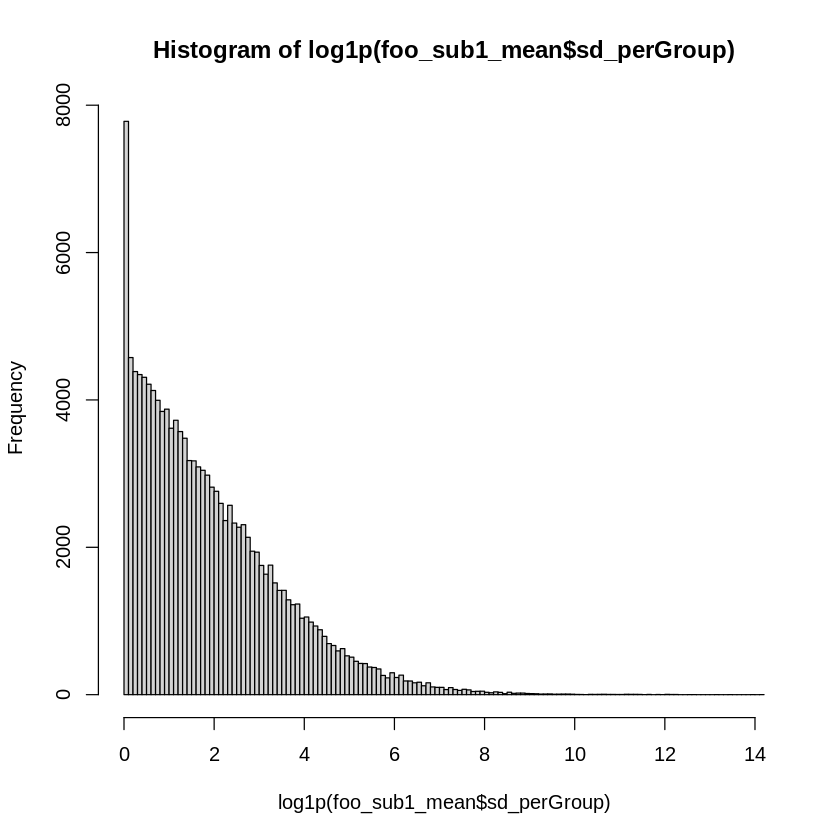

png 
  2

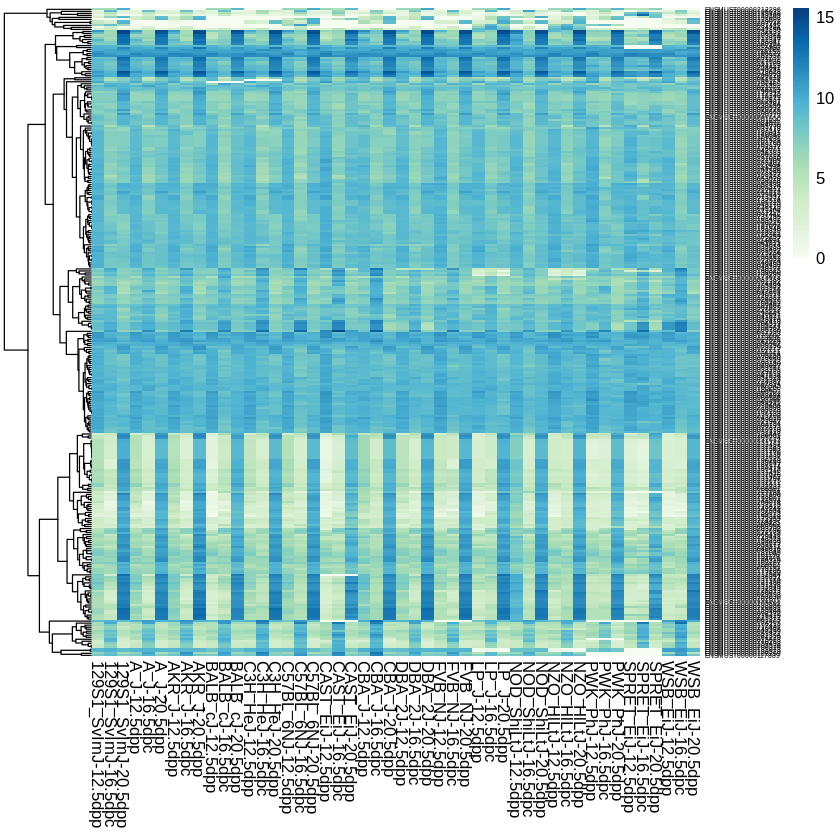

In [29]:

##NEXT IS THE TOP 15% VARIANT miRNA plot on the means. Then the subset more useful miRNA plot
library(pheatmap)

foo_sub_1 <- as.data.frame.matrix(foo_sub_1) #convert from matrix to data frame
## use for eg foo$`hPGC_M_Wk9_n1` <- foo$`hPGC-M-Wk9_2` if only want one biol replicate

colnames(foo_sub_1)

head(foo_sub_1[ , grepl( "^129S1_SvImJ-12.5dpp" , names( foo_sub_1 ) ) ])
foo_sub1_mean = data.frame(matrix(NA, nrow = nrow(foo_sub_1), ncol = 0))
row.names(foo_sub1_mean) <- row.names(foo_sub_1)
for (sample in samplenames) {
foo_sub1_mean[sample] <- apply(foo_sub_1[ , grepl(paste0( "^",sample) , names( foo_sub_1 ) ) ], 1, mean)
}
head(foo_sub1_mean) 

foo_sub1_mean$sd_perGroup <- apply(foo_sub1_mean,1,sd)
hist(log1p(foo_sub1_mean$sd_perGroup),breaks = 200)


nrow(foo_sub1_mean)
3959
foo_sub1_mean_top15sd <- foo_sub1_mean[foo_sub1_mean$sd_perGroup>3959,1:48]
head(foo_sub1_mean_top15sd)
foo_sub1_mean_top15sd$ID<-rownames(foo_sub1_mean_top15sd)
head(foo_sub1_mean_top15sd)



save_pheatmap_pdf <- function(x, filename, width=15, height=25) {
    stopifnot(!missing(x))
    stopifnot(!missing(filename))
    pdf(filename, width=width, height=height,paper="special")
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

savePheatmap <- pheatmap(log1p(foo_sub1_mean_top15sd[,1:48]),width=30000,height=50000, border_color = NA,show_rownames = T, cluster_cols = F, labels_row = foo_sub1_mean_top15sd$ID,cutree_rows = 1,fontsize_row = 4, color = hmcol)
save_pheatmap_pdf(savePheatmap,"InitialPheatMap.pdf")

png 
  2

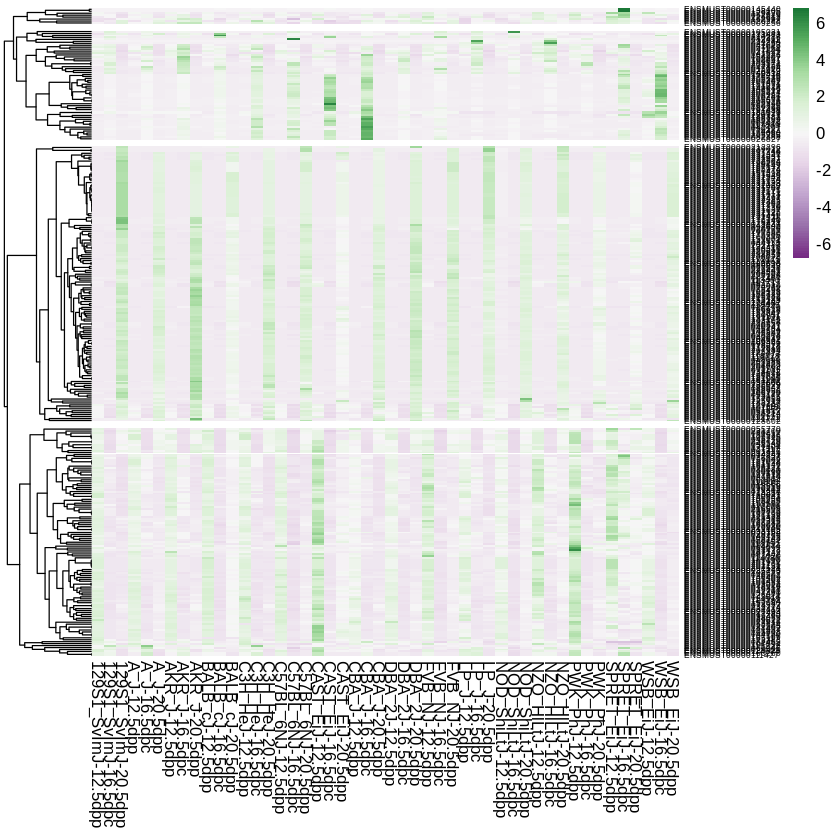

In [30]:
##for z-score
myCol = colorRampPalette(brewer.pal(9,"PRGn"))(100)

savePheatmapZScore <- pheatmap(foo_sub1_mean_top15sd[,1:48], border_color = NA,show_rownames = T,scale = "row",labels_row = foo_sub1_mean_top15sd$ID,cutree_rows = 4,fontsize_row = 5, cluster_cols = F, color = myCol)
save_pheatmap_pdf(savePheatmapZScore,"InitialPheatMap_zScore.pdf")

png 
  2

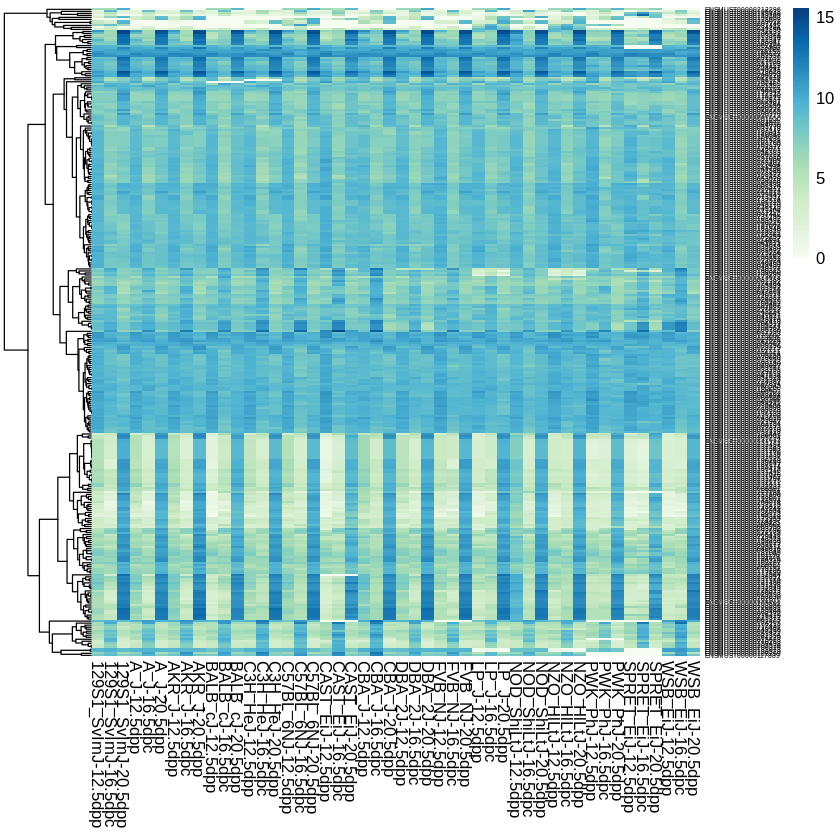

In [31]:
##For log with predeterminde column orderr use cluster_cols = F

logPheatMap <- pheatmap(log1p(foo_sub1_mean_top15sd[,1:48]), border_color = NA,show_rownames = T, cluster_cols = F, labels_row = foo_sub1_mean_top15sd$ID,cutree_rows = 1,fontsize_row = 4, color = hmcol)
save_pheatmap_pdf(logPheatMap,"InitialPheatMap_log.pdf")